# **Assignment - 2: Building `mini-Copilot`**
## **Sequential Code Generation with Recurrent Architectures**
### **Course:** **NLP (CS60075)**  

---
**Name:** *Tuhin Mondal*  | **Roll No:** *22CS10087* | **Github:** [Ecolash - Tuhin Mondal](https://github.com/Ecolash)

---



## **Task 1: Data Preparation**
---



### **1.1) Imports and Configuration**

In [ ]:
import math
import os, sys, time
import numpy as np
import pandas as pd
import collections
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### **1.2) Loading CodeXGLUE (Python) dataset**

In [ ]:
from datasets import load_dataset
from typing import List, Tuple

def load_codexglue():
    try:
        print("Loading CodeXGLUE (Python) dataset...\n")
        train = load_dataset("google/code_x_glue_cc_code_completion_token", "python", split="train")
        test  = load_dataset("google/code_x_glue_cc_code_completion_token", "python", split="test")
        # print(train_dataset.column_names)
        # print(train[0])
        # print(test[0])

        print(f"[>] Train split loaded: {len(train)} samples")
        print(f"[>] Test split loaded: {len(test)} samples")

    except Exception as e:
        raise RuntimeError(f"[-] Failed to load CodeXGLUE dataset: {e}")

    X = train["code"]
    y = test["code"]
    return X, y


In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# from google.colab import userdata
# hf_token = userdata.get('HF_TOKEN')

from huggingface_hub import login
login(token = hf_token)

train_data, test_data = load_codexglue()

# Reduced for fast code check
# train_data = train_data[:int(len(train_data) * 0.001)]
# test_data = test_data[:int(len(test_data) * 0.005)]

print("\nSamples:")
print("Train Seq [0]:", train_data[0][:25], "...")
print("Test Seq [0]:", test_data[0][:25], "...")

Loading CodeXGLUE (Python) dataset...



README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00002.parquet:   0%|          | 0.00/70.1M [00:00<?, ?B/s]

python/train-00001-of-00002.parquet:   0%|          | 0.00/70.9M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/69.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

[>] Train split loaded: 100000 samples
[>] Test split loaded: 50000 samples

Samples:
Train Seq [0]: ['<s>', 'from', 'bootstrap', 'import', 'Bootstrap', '<EOL>', 'from', 'fund', 'import', 'InstantPaymentNotificationHandler', '<EOL>', 'from', 'fund', 'import', 'ThankYouHandler', '<EOL>', 'from', 'view', 'import', '*', '<EOL>', 'mapping', '=', '[', '('] ...
Test Seq [0]: ['<s>', 'from', 'django', '.', 'utils', '.', 'translation', 'import', 'ugettext_lazy', 'as', '_', '<EOL>', 'from', 'horizon', 'import', 'tabs', '<EOL>', 'class', 'NetworkProfileTab', '(', 'tabs', '.', 'Tab', ')', ':'] ...


### **1.3) Vocabulary Creation**

We create the vocabulary only from training data. We use 10,000 most freq unique tokens in training set + 5 special tokens:


`<PAD>`: Padding token used to equalize sequence lengths during batching
(index 0).

`<UNK>`: Represents unknown or out-of-vocabulary tokens (includes less freuent tokens).

`<EOL>`: Marks the end of a line in multi-line code sequences.

`<s>`: Denotes the start of a new sequence.

`</s>`: Indicates the end of a sequence.




In [ ]:
MAX_SEQ_LEN = 1000 # max len for padding/truncating input seq
VOCAB_SIZE = 10000

# Tokens that I found in the Dataset already
EOL_TOKEN = "<EOL>"
START_TOKEN = "<s>"
END_TOKEN = "</s>"

# New tokens needed for model trainig
PAD_TOKEN = "<PAD>" # for making seqs of equal length
UNK_TOKEN = "<UNK>" # for OOV words

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, EOL_TOKEN, START_TOKEN, END_TOKEN]
PAD_IDX = SPECIAL_TOKENS.index(PAD_TOKEN) # MUST be idx 0 for nn.CrossEntropyLoss ignore_index

In [ ]:
def build_vocab(token_lists):
    print("Building vocabulary from the Training Data...")

    tokens = [token for seq in token_lists for token in seq]
    counts = collections.Counter(tokens)
    # print(len(tokens))
    # print(tokens[:10])

    tokens = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    top_tokens = []
    for token, count in tokens:
        if token not in SPECIAL_TOKENS: top_tokens.append(token)
        if len(top_tokens) >= VOCAB_SIZE: break

    # Build vocab from top 10k tokens + special tokens
    # IMP: We need to make sure first token in vocab is PAD_TOKEN
    vocab = SPECIAL_TOKENS + top_tokens
    # print(voacb[0])
    # top10 = vocab[:10]
    # bot10 = vocab[-10:]
    # df = pd.DataFrame({"top": top10, "bottom": last10})
    # print(df.to_string(index=False))

    tok2idx = {}
    idx2tok = {}
    for idx, tok in enumerate(vocab):
        tok2idx[tok] = idx
        idx2tok[idx] = tok

    return tok2idx, idx2tok, counts

In [ ]:
tok2idx, idx2tok, cnt = build_vocab(train_data)
# print(tok2idx)
# print(idx2tok)
# print(cnt)

VOCAB_SIZE_FINAL = len(tok2idx)
UNK_IDX = tok2idx[UNK_TOKEN]
top20 = [idx2tok[i] for i in range(20)]

print(f"\n[+] Final Vocabulary Size (V): {VOCAB_SIZE_FINAL:,}")
print(f"[+] <PAD> index: {PAD_IDX}")
print(f"[+] <UNK> index: {UNK_IDX}\n")
print(f"[+] Vocabulary: {top20}\n")

Building vocabulary from the Training Data...

[+] Final Vocabulary Size (V): 10,005
[+] <PAD> index: 0
[+] <UNK> index: 1

[+] Vocabulary: ['<PAD>', '<UNK>', '<EOL>', '<s>', '</s>', '.', '(', ')', ',', '=', ':', 'self', '[', ']', 'def', "''", 'if', 'return', 'import', '""']



### **1.4) Sequencing and Validation Set Creation**

Converting token sequences to numerical indices, truncating sequences longer than MAX_SEQ_LEN = 1000.

In [ ]:
def numericalize(token_list, tok2idx, max_len = MAX_SEQ_LEN) -> List[List[int]]:
    num_data = []
    for seq in token_list:
        num_seq = [tok2idx.get(token, UNK_IDX) for token in seq]
        if len(num_seq) > max_len: num_seq = num_seq[:max_len]
        num_data.append(num_seq)

    # print(num_data)
    return num_data

print(f"Numericalizing {len(train_data)} training samples and {len(test_data)} test samples...")

train_numerical = numericalize(train_data, tok2idx)
test_numerical = numericalize(test_data, tok2idx)

print(f"[+] Numericalization complete. Train samples: {len(train_numerical)}, Test samples: {len(test_numerical)}")

# print(train_numerical[0][:10])
# print(len(train_numerical[0]))
# print(test_numerical[0][:10])
# print(len(test_numerical[0]))

Numericalizing 100000 training samples and 50000 test samples...
[+] Numericalization complete. Train samples: 100000, Test samples: 50000


In [ ]:
print("\nSplitting Numerical Training Data into Train (80%) and Validation (20%)\n")

train_size = int(0.8 * len(train_numerical))
val_size = len(train_numerical) - train_size
rng = torch.Generator().manual_seed(42)

train_subset, val_subset = torch.utils.data.random_split(train_numerical, [train_size, val_size])
# print(type(train_subset))
# print(type(val_subset))
# print(type(test_subset))

# NOTE: torch.utils.data.random_split returns Subset objects.
# So we need to convert them back into standard Python lists.
train_numerical = list(train_subset)
val_numerical = list(val_subset)

print(f"[+] Training Set Size: {len(train_numerical)} sequences (80%)")
print(f"[+] Validation Set Size: {len(val_numerical)} sequences (20%)")
print(f"[+] Test Set Size: {len(test_numerical)} sequences")


Splitting Numerical Training Data into Train (80%) and Validation (20%)

[+] Training Set Size: 80000 sequences (80%)
[+] Validation Set Size: 20000 sequences (20%)
[+] Test Set Size: 50000 sequences


### **1.5) Building Loaders (Dataset and DataLoader)**

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch import Tensor

# class CodeCompletionDataset(Dataset):
#     def __init__(self, data): self.dataset = data
#     def __len__(self): return len(self.dataset)

class CodeCompletionDataset(Dataset):
    def __init__(self, data: List[List[int]]):
        self.data_X, self.data_Y = [], []
        for seq in data:
            if len(seq) <= 1: continue
            x = torch.tensor(seq[:-1], dtype=torch.long)
            y = torch.tensor(seq[1:], dtype=torch.long)
            self.data_X.append(x)
            self.data_Y.append(y)

        print(f"[+] Dataset initialized with {len(self.data_X)} samples.")

    def __len__(self): return len(self.data_X)
    def __getitem__(self, idx): return self.data_X[idx], self.data_Y[idx]

print("\nCreating PyTorch Dataset objects...")
train_dataset = CodeCompletionDataset(train_numerical)
val_dataset   = CodeCompletionDataset(val_numerical)
test_dataset  = CodeCompletionDataset(test_numerical)


Creating PyTorch Dataset objects...
[+] Dataset initialized with 80000 samples.
[+] Dataset initialized with 20000 samples.
[+] Dataset initialized with 50000 samples.


In [ ]:
# Default DataLoader can't batch variable-length sequences.
# So I defined a custom collate_fn to pad each batch to equal length using PAD_IDX

def collate_fn(batch):
    X, y = zip(*batch)
    X_padded = pad_sequence(X, batch_first = True, padding_value = PAD_IDX)
    y_padded = pad_sequence(y, batch_first = True, padding_value = PAD_IDX)
    # print(X_padded.shape)
    # print(y_padded.shape)
    return X_padded, y_padded

In [ ]:
BATCH_SIZE = 32 # 64 => FAILS bcz memory overflows for LSTM
print(f"\nCreating PyTorch DataLoaders with BATCH_SIZE = {BATCH_SIZE}...")

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle= True,
    collate_fn=collate_fn,
    num_workers = 2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn =collate_fn,
    num_workers= 2,
    pin_memory =True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn =collate_fn,
    num_workers= 2,
    pin_memory=True
)

# x, y = next(iter(train_loader))
# print("Batch i/p shape:", x.shape)
# print("Batch o/p shape:", y.shape)

print(f"[+] Train batches: {len(train_loader)}")
print(f"[+] Validation batches: {len(val_loader)}")
print(f"[+] Test batches: {len(test_loader)}")
print("\nData Preparation is complete")


Creating PyTorch DataLoaders with BATCH_SIZE = 32...
[+] Train batches: 2500
[+] Validation batches: 625
[+] Test batches: 1563

Data Preparation is complete


In [ ]:
# # check loader
# for x, y in train_loader:
#     print(x.shape)
#     print(y.shape)
#     print(x.dtype)
#     print(x.device)
#     break

## **Task 2: Baseline Model - Comparision**
---



### **2.1) RNN Model Implementation**
#### **Architecture:**

1) **Embedding Layer**: Converts integer token IDs into dense vector embeddings.
2) **Recurrent Stack (RNN Layer)**: It is a multi-layer vanilla RNN (`tanh` activation).
3) **Dropout Layer**: For o/p regularization, prevent overfitting during training.
4) **Fully Connected (o/p) Layer**: It projects hidden states to vocabulary space.
   
**Forward Pass Summary:** `x -> embedding -> rnn -> dropout -> linear -> logits`


In [ ]:
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2

# DROPOUT Selection (see report for details)
# 0.5 => validation accuracy osscilating
# 0.3 worked better (Range: 0.2 - 0.5)

# DROPOUT_PROB = 0.5
DROPOUT_PROB = 0.3

LEARNING_RATE = 1e-3
NUM_EPOCHS = 12

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout_prob, pad_idx):
        super(RNNModel, self).__init__()
        self.pad_idx = pad_idx

        # 1) Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 2) Recurrent Stack (2-layer RNN)
        self.rnn = nn.RNN(
            input_size = embed_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            dropout = dropout_prob,
            batch_first = True,
            nonlinearity = 'tanh' # choosing tanh (see report for details)
        )

        # 3) Dropout before o/p Layer
        self.dropout_out = nn.Dropout(dropout_prob)

        # 4) Output Layer (Linear layer for vocab pred)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch_size, seq_len)
        emb = self.embedding(x)
        # print(emb.shape)

        rnn_output, hidden = self.rnn(emb)
        # print(rnn_output.shape)
        # print(hidden.shape)

        dropout_output = self.dropout_out(rnn_output)
        logits = self.fc(dropout_output)
        # print(logits.shape)

        return logits

### **2.2) LSTM Model Implementation**
#### **Architecture**

1) **Embedding Layer**: Converts integer token IDs into dense vector embeddings.
2) **Recurrent Stack (LSTM Layer)**:It is a multi-layer LSTM capturing long-term dependencies in sequences.
3) **Dropout Layer**: For o/p regularization, prevent overfitting during training.
4) **Fully Connected (Output) Layer**: It projects LSTM hidden states to the vocabulary space.

**Forward Pass Summary:** `x -> embedding -> lstm -> dropout -> linear -> logits`


In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout_prob, pad_idx):
        super(LSTMModel, self).__init__()
        self.pad_idx = pad_idx

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 2. Recurrent Stack (2-layer LSTM)
        self.lstm = nn.LSTM(
            input_size = embed_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            dropout = dropout_prob,
            batch_first=True,
        )

        # 3. Dropout before Output Layer
        self.dropout_out = nn.Dropout(dropout_prob)

        # 4. Output Layer (Linear layer for vocabulary prediction)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        emb = self.embedding(x)
        # print(emb.shape)

        lstm_output, (hidden, cell) = self.lstm(emb)
        # print(lstm_output.shape)
        # print(hidden.shape)
        # print(cell.shape)

        dropped_output = self.dropout_out(lstm_output)
        logits = self.fc(dropped_output)
        # print(logits.shape)
        return logits

### **2.3) Training & Utility Function**


In [ ]:
def params(model):
    # Return the total no. of trainable params in a model
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable

def topK(predictions, targets, k = 5, ignore_index=PAD_IDX):
    mask = (targets != ignore_index)
    pred = predictions[mask]
    targets = targets[mask]

    topk = torch.topk(pred, k=k, dim=1)[1]
    correct = (topk == targets.unsqueeze(1)).any(dim=1)
    n_correct = correct.sum().item() # Counting correct
    n_tokens = mask.sum().item()
    return n_correct, n_tokens

def perplexity(loss):
    return torch.exp(loss)


In [ ]:
# Trainer function to run one full training step for the model
def trainer(model, inputs, targets, criterion, optim):
    inputs = inputs.to(device)
    targets = targets.to(device)
    optim.zero_grad() # for clearing old gradeints

    logits = model(inputs).view(-1, VOCAB_SIZE_FINAL)
    targets = targets.view(-1)

    loss = criterion(logits, targets)
    loss.backward()
    optim.step()

    return loss.item() * targets.shape[0], targets.shape[0]

# Validator function to evaluate the model on validaton data
# Note: No gradient updates done in this step
def validator(model, inputs, targets, criterion):
    inputs = inputs.to(device)
    targets = targets.to(device)
    logits = model(inputs).view(-1, VOCAB_SIZE_FINAL)
    targets = targets.view(-1)
    # print(logits.shape)

    loss = criterion(logits, targets)
    # print(loss.item())

    correct, tokens = topK(logits, targets, k = 5) # Top-5 Acc as per qsn
    # print(correct, tokens)

    return loss.item() * targets.shape[0], correct, tokens

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, N, model_name):
    model.to(device)
    best_val_acc = 0.0
    PATH = f"{model_name}_22CS10087.pt"
    start = time.time()

    loss_hist = []
    vacc_hist= []
    vppl_hist = []

    print(f"\n{'='*70}")
    print(f"[*] TRAINING: {model_name}")
    print(f"{'='*70}")

    header = f"{'Epoch':>5} | {'Train Loss':>12} | {'Val Acc (%)':>12} | {'Val PPL':>10}"
    print(header)
    print("-" * len(header))

    for epoch in range(1, N + 1):
        # --- Training Phase ---
        model.train()
        L = 0  # L = Total training loss
        T = 0  # T = Total token cnts
        for x, y in train_loader:
            BL, BT = trainer(model, x, y, criterion, optimizer)
            # BL = traning loss for this batch
            # BT = total token cnts for this batch
            L += BL
            T += BT

        avg_L = L / T
        loss_hist.append(avg_L)

        # --- Validation Phase ---
        model.eval() # VVI: Turning off dropout, batch norm updates, etc.
        VL = 0 # VL = Total validation loss
        VC = 0 # VC = Total correct predictions (for top-k)
        VT = 0 # VT = Total token cnts in validaton set
        with torch.no_grad():
            for x_val, y_val in val_loader:
                BL, BC, BT = validator(model, x_val, y_val, criterion)
                # BL = batch validation loss
                # BC = correct predictions
                # BT = total token cnts for this batch
                VL += BL
                VC += BC
                VT += BT

        avg_VL = VL / VT
        val_acc = (VC / VT) * 100
        val_ppl = perplexity(torch.tensor(avg_VL))
        # print(val_acc, val_ppl)

        vacc_hist.append(val_acc)
        vppl_hist.append(val_ppl.item())

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, PATH)

        print(f"{epoch:>5} | {avg_L:>12.4f} | {val_acc:>12.2f} | {val_ppl.item():>10.2f}")

    end = time.time()
    train_time = (end - start) / 60 # (to mins)
    model = torch.load(PATH, weights_only = False).to(device)

    print(f"{'='*70}")
    print(f"[+] Training finished for {model_name}")
    print(f"[+] Best Validation Top-5 Accuracy: {best_val_acc:.2f}%")
    print(f"[+] Total Training Time: {train_time:.2f} minutes")
    print(f"{'='*70}")

    return model, loss_hist, vacc_hist, vppl_hist, train_time

### **2.4) RNN Model Training**


In [ ]:
rnn_model = RNNModel(
    vocab_size = VOCAB_SIZE_FINAL,       # Total vocabulary size
    embed_dim  = EMBEDDING_DIM,          # Embedding vector dim
    hidden_dim = HIDDEN_DIM,             # Hidden state dim of RNN
    num_layers = NUM_LAYERS,             # Number of stacked RNN layers
    dropout_prob = DROPOUT_PROB,         # Dropout probability between layers
    pad_idx = PAD_IDX                    # Padding token index
).to(device)

print(f"[+] RNN Trainable Parameters: {params(rnn_model)}")

# Observed osscilations for LEARNING_RATE = 1e-3 (reducing to 1e-4)
# Observed slow growth for LEARNING_RATE = 1e-4 (increasing to 5e-4)
# see report for more details...

rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=5e-4)
rnn_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

best_rnn_model, rnn_train_loss, rnn_val_acc, rnn_val_ppl, rnn_train_time = train_model(
    rnn_model,
    train_loader,
    val_loader,
    rnn_criterion,
    rnn_optimizer,
    NUM_EPOCHS,
    "RNN_Baseline"
)

[+] RNN Trainable Parameters: 8613397

[*] TRAINING: RNN_Baseline
Epoch |   Train Loss |  Val Acc (%) |    Val PPL
------------------------------------------------
    1 |       2.4157 |        80.74 |     106.45
    2 |       2.0784 |        81.72 |      84.06
    3 |       1.9834 |        82.58 |      70.24
    4 |       1.9336 |        82.77 |      67.12
    5 |       1.9000 |        83.25 |      61.20
    6 |       1.8729 |        83.40 |      59.40
    7 |       1.8499 |        83.70 |      55.48
    8 |       1.8462 |        83.75 |      54.90
    9 |       1.8316 |        83.85 |      53.84
   10 |       1.8498 |        83.79 |      54.87
   11 |       1.8617 |        82.57 |      71.56
   12 |       1.8447 |        83.87 |      53.66
[+] Training finished for RNN_Baseline
[+] Best Validation Top-5 Accuracy: 83.87%
[+] Total Training Time: 145.80 minutes


### **2.5) LSTM Model Training**


In [ ]:
lstm_model = LSTMModel(
    vocab_size = VOCAB_SIZE_FINAL,       # Total vocab size
    embed_dim  = EMBEDDING_DIM,          # Embedding vector dim
    hidden_dim = HIDDEN_DIM,             # Hidden state dim of LSTM
    num_layers = NUM_LAYERS,             # Number of stacked LSTM layers
    dropout_prob = DROPOUT_PROB,         # Dropout probability between layers
    pad_idx = PAD_IDX                    # Padding token index
).to(device)

print(f"[+] LSTM Trainable Parameters: {params(lstm_model)}")

# Got Standard results for LEARNING_RATE = 1e-3
# Still seems like we can achieve more (increasing LR to 0.002)
# see report for more details...

lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=2e-3)
lstm_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

best_lstm_model, lstm_train_loss, lstm_val_acc, lstm_val_ppl, lstm_train_time = train_model(
    lstm_model,
    train_loader,
    val_loader,
    lstm_criterion,
    lstm_optimizer,
    NUM_EPOCHS,
    "LSTM_Baseline"
)

[+] LSTM Trainable Parameters: 11372053

[*] TRAINING: LSTM_Baseline
Epoch |   Train Loss |  Val Acc (%) |    Val PPL
------------------------------------------------
    1 |       2.5668 |        81.92 |      81.28
    2 |       1.8568 |        84.86 |      44.16
    3 |       1.6822 |        86.17 |      34.07
    4 |       1.5837 |        86.96 |      29.09
    5 |       1.5187 |        87.45 |      26.42
    6 |       1.4746 |        87.78 |      24.69
    7 |       1.4394 |        88.07 |      23.42
    8 |       1.4121 |        88.31 |      22.40
    9 |       1.3899 |        88.46 |      21.72
   10 |       1.3717 |        88.58 |      21.20
   11 |       1.3557 |        88.73 |      20.61
   12 |       1.3416 |        88.81 |      20.31
[+] Training finished for LSTM_Baseline
[+] Best Validation Top-5 Accuracy: 88.81%
[+] Total Training Time: 209.59 minutes


### **2.6) Training Result Comparision**


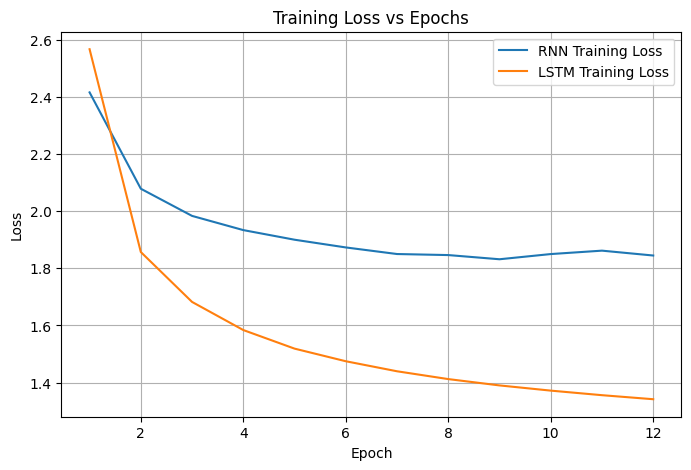

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, NUM_EPOCHS + 1)

# 1. Training Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_train_loss, label='RNN Training Loss')
plt.plot(epochs, lstm_train_loss, label='LSTM Training Loss')

plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()

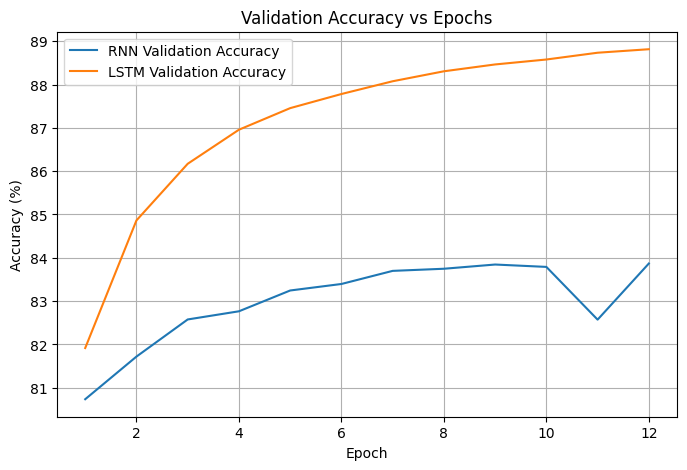

In [ ]:
# 2. VAl Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_val_acc, label='RNN Validation Accuracy')
plt.plot(epochs, lstm_val_acc, label='LSTM Validation Accuracy')

plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.legend()
plt.grid(True)
plt.show()

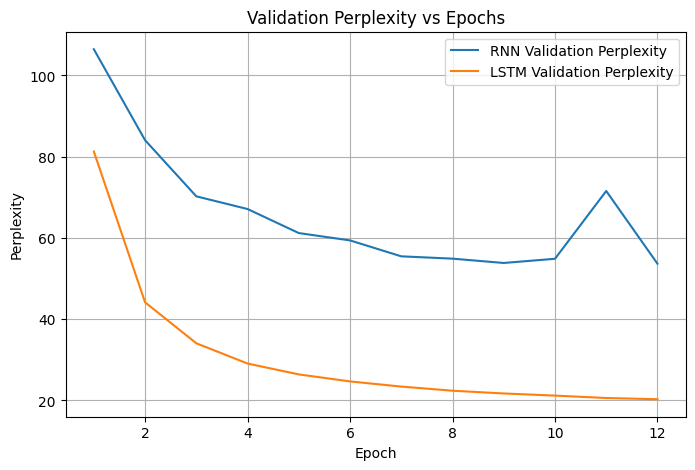

In [ ]:
# 3. Val Perplexity
plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_val_ppl, label='RNN Validation Perplexity')
plt.plot(epochs, lstm_val_ppl, label='LSTM Validation Perplexity')

plt.title('Validation Perplexity vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')

plt.legend()
plt.grid(True)
plt.show()

### **2.7) Final Evaluation on Test Set**


In [ ]:
def evaluate_test_set(model, test_loader, criterion):
    model.eval()  # disable dropout, batch norm updates, etc.

    TL = 0  # TL = total test loss
    TC = 0  # TC = total correct predictions (top-5)
    TT = 0  # TT = total tokens seen in test set

    with torch.no_grad():  # no gradient updates during testing
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x).view(-1, VOCAB_SIZE_FINAL)
            y_flat = y.view(-1)

            BL = criterion(logits, y_flat).item() * y_flat.shape[0]
            BC, BT = topK(logits, y_flat, k=5)
            # BL = batch test loss
            # BC = correct predictions
            # BT = total token cnts for this batch
            TL += BL
            TC += BC
            TT += BT

    avg_TL = TL / TT
    test_acc = (TC / TT) * 100 if TT > 0 else 0.0
    test_ppl = perplexity(torch.tensor(avg_TL)).item()

    return test_acc, test_ppl

**`Checkpoint (starting again with downloaded models here)`**

In [ ]:
print("Loading and evaluating best baseline checkpoints...")

rnn_final = torch.load("RNN_Baseline_22CS10087.pt", weights_only = False).to(device)
print(f"\n[+] Loaded RNN_Baseline_22CS10087.pt successfully.")

lstm_final = torch.load("LSTM_Baseline_22CS10087.pt", weights_only = False).to(device)
print(f"[+] Loaded LSTM_Baseline_22CS10087.pt successfully.\n")

rnn_test_acc, rnn_test_ppl = evaluate_test_set(rnn_final, test_loader, rnn_criterion)
print(f"[+] RNN Test Accuracy: {rnn_test_acc:.2f}%")
print(f"[+] RNN Test Perplexity: {rnn_test_ppl:.2f}")

lstm_test_acc, lstm_test_ppl = evaluate_test_set(lstm_final, test_loader, lstm_criterion)
print(f"\n[+] LSTM Test Accuracy: {lstm_test_acc:.2f}%")
print(f"[+] LSTM Test Perplexity: {lstm_test_ppl:.2f}")

eval = {
    'RNN': {
        'Acc': rnn_test_acc,
        'PPL': rnn_test_ppl,
        'Params': params(rnn_final),
        'Time': rnn_train_time
    },
    'LSTM': {
        'Acc': lstm_test_acc,
        'PPL': lstm_test_ppl,
        'Params': params(lstm_final),
        'Time': lstm_train_time
    }
}
print("\n[+] Evals for Baseline Models\n")
print(f"{'Model':<10} {'Top-5 Acc (%)':>15} {'PPL':>12} {'Trainable Params':>22} {'Train Time (min)':>18}")
print("-" * 80)

print(f"{'RNN':<10} {eval['RNN']['Acc']:>15.2f} {eval['RNN']['PPL']:>12.2f} "
f"{eval['RNN']['Params']:>22,} {eval['RNN']['Time']:>18.2f}")

print(f"{'LSTM':<10} {eval['LSTM']['Acc']:>15.2f} {eval['LSTM']['PPL']:>12.2f} "
f"{eval['LSTM']['Params']:>22,} {eval['LSTM']['Time']:>18.2f}")

print("-" * 80)



Loading and evaluating best baseline checkpoints...

[+] Loaded RNN_Baseline_22CS10087.pt successfully.
[+] Loaded LSTM_Baseline_22CS10087.pt successfully.

[+] RNN Test Accuracy: 83.93%
[+] RNN Test Perplexity: 43.64

[+] LSTM Test Accuracy: 88.89%
[+] LSTM Test Perplexity: 17.26

[+] Evals for Baseline Models

Model        Top-5 Acc (%)          PPL       Trainable Params   Train Time (min)
--------------------------------------------------------------------------------
RNN                  83.93        43.64              8,613,397             145.80
LSTM                 88.89        17.26             11,372,053             209.59
--------------------------------------------------------------------------------


## **Task 3: Residual Recurrent Model**
---



### **3.1) Residual LSTM Model Implementation**  
#### **Architecture Components**

1) **Embedding Layer:** As described earlier
2) **First LSTM Layer (L1)** It receives the embeddings and captures sequential dependencies in the input data.
3) **Dropout (Between L1 and L2)**: To prevent overfitting
4) **Second LSTM Layer (L2)**:  It processes the regularised o/p from L1 for better results.
5) **Residual Connection**: The o/ps from L1 and L2 are added element-wise
6) **Dropout (Before Output Layer)**: To regularize the final o/p.  
7) **Fully Connected (Output) Layer**: It projects o/p of residual conn to the vocabulary space.

**Forward Pass Summary:**  
`x -> embedding -> lstm1 -> dropout -> lstm2 -> (residual add) -> dropout -> linear -> logits`


**Notes (explanation behind my choices):**
- In order to preserve the information req. for the residual connection, dropout is not used in the first layer L1.  
- By maintaining data from previous layers, residual conections improve gradient flow & stablize training.  

In [ ]:
class ResidualLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout_prob, pad_idx):
        # Note: This model is fixed to 2 layers for the residual connection
        super(ResidualLSTMModel, self).__init__()
        self.pad_idx = pad_idx

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 2. First LSTM Layer (Dropout is NOT applied here)
        self.lstm1 = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )

        # 3. Second LSTM Layer
        self.lstm2 = nn.LSTM(
            input_size=hidden_dim, # Input to L2 is o/p of L1
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )

        # 4. Dropout layers (Between L1 and L2, and before FC)
        self.dropout_rec = nn.Dropout(dropout_prob)
        self.dropout_out = nn.Dropout(dropout_prob)

        # 5. Output Layer
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch_size, seq_len)
        emb = self.embedding(x)
        # print(emb.shape)

        H1, _ = self.lstm1(emb)
        H1_dropped = self.dropout_rec(H1)
        H2, _ = self.lstm2(H1_dropped)
        # print(H1.shape)
        # print(H1_dropped.shape)
        # print(H2.shape)

        H_comb = H1 + H2
        # print(H_comb.shape)

        dropped_output = self.dropout_out(H_comb)
        logits = self.fc(dropped_output)
        # print(logits.shape)
        return logits

### **3.2) Residual LSTM Model Training**


In [ ]:
residual_model = ResidualLSTMModel(
    vocab_size   = VOCAB_SIZE_FINAL,     # Total vocab size
    embed_dim    = EMBEDDING_DIM,        # Embeding vector dimension
    hidden_dim   = HIDDEN_DIM,           # Hidden state dim
    dropout_prob = DROPOUT_PROB,         # Dropout prob b/w layers
    pad_idx      = PAD_IDX               # Padding token idx
).to(device)

print(f"[+] Residual LSTM Trainable Parameters: {params(residual_model)}")

# Got Standard results for LEARNING_RATE = 1e-3 (can try higher)
# Still seems like we can achieve more (increasing LR to 0.002)
# # see report for more details...

residual_optimizer = torch.optim.Adam(residual_model.parameters(), lr=2e-3)
residual_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

best_residual_model, residual_train_loss, residual_val_acc, residual_val_ppl, residual_train_time = train_model(
    residual_model,
    train_loader,
    val_loader,
    residual_criterion,
    residual_optimizer,
    NUM_EPOCHS,
    "Residual_LSTM"
)

[+] Residual LSTM Trainable Parameters: 11372053

[*] TRAINING: Residual_LSTM
Epoch |   Train Loss |  Val Acc (%) |    Val PPL
------------------------------------------------
    1 |       2.0312 |        85.42 |      41.68
    2 |       1.6113 |        87.25 |      28.78
    3 |       1.4811 |        88.07 |      24.28
    4 |       1.4066 |        88.57 |      21.93
    5 |       1.3583 |        88.87 |      20.58
    6 |       1.3239 |        89.08 |      19.75
    7 |       1.2984 |        89.30 |      19.05
    8 |       1.2769 |        89.37 |      18.73
    9 |       1.2596 |        89.47 |      18.38
   10 |       1.2452 |        89.59 |      18.00
   11 |       1.2337 |        89.63 |      17.84
   12 |       1.2228 |        89.69 |      17.68
[+] Training finished for Residual_LSTM
[+] Best Validation Top-5 Accuracy: 89.69%
[+] Total Training Time: 212.74 minutes


### **3.3) Training Result Comparision (with Baseline Models)**

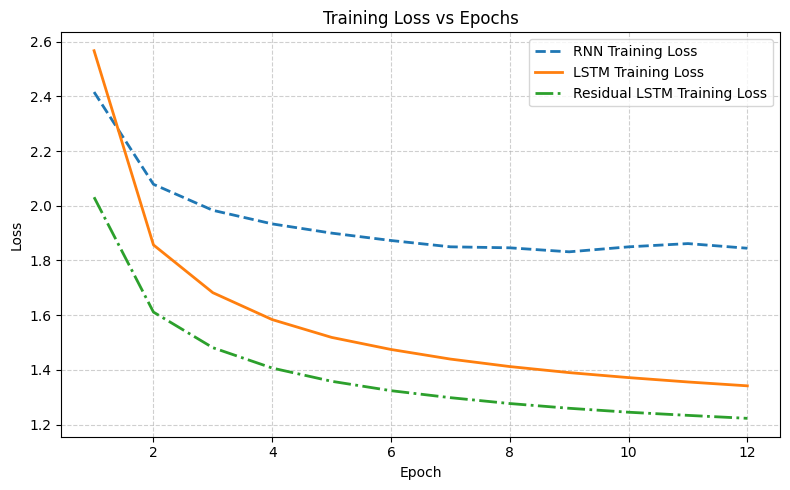

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_train_loss, label='RNN Training Loss', linestyle='--', linewidth=2)
plt.plot(epochs, lstm_train_loss, label='LSTM Training Loss', linestyle='-', linewidth=2)
plt.plot(epochs, residual_train_loss, label='Residual LSTM Training Loss', linestyle='-.', linewidth=2)

plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

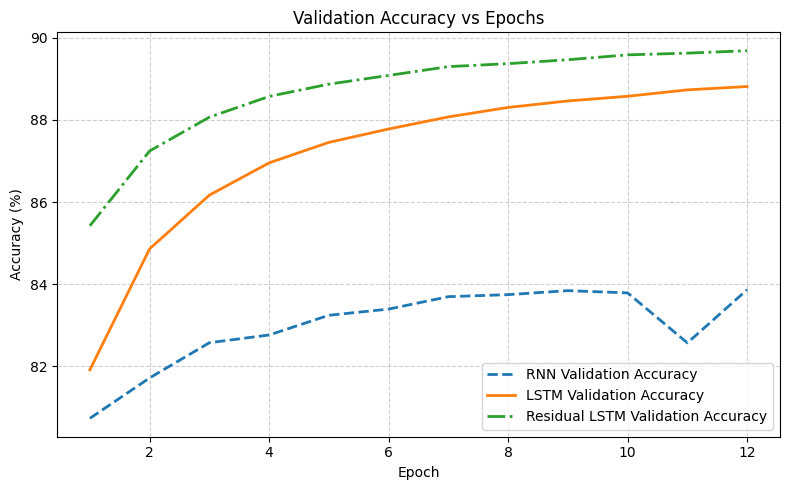

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_val_acc, label='RNN Validation Accuracy', linestyle='--', linewidth=2)
plt.plot(epochs, lstm_val_acc, label='LSTM Validation Accuracy', linestyle='-', linewidth=2)
plt.plot(epochs, residual_val_acc, label='Residual LSTM Validation Accuracy', linestyle='-.', linewidth=2)

plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

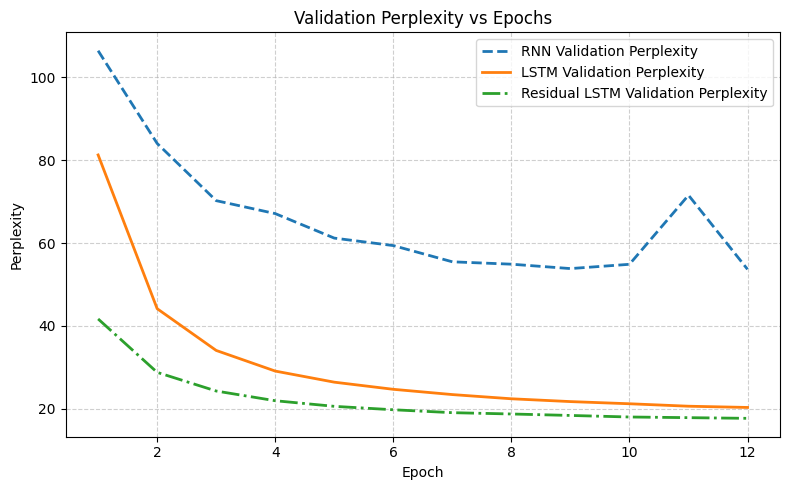

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_val_ppl, label='RNN Validation Perplexity', linestyle='--', linewidth=2)
plt.plot(epochs, lstm_val_ppl, label='LSTM Validation Perplexity', linestyle='-', linewidth=2)
plt.plot(epochs, residual_val_ppl, label='Residual LSTM Validation Perplexity', linestyle='-.', linewidth=2)

plt.title('Validation Perplexity vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **3.4) Final Evaluation on Test Set**

In [ ]:
residual_final = torch.load("Residual_LSTM_22CS10087.pt", weights_only = False).to(device)
print(f"[+] Loaded Residual_LSTM_22CS10087.pt successfully.\n")

residual_test_acc, residual_test_ppl = evaluate_test_set(residual_final, test_loader, residual_criterion)
print(f"[+] Residual Test Accuracy: {residual_test_acc:.2f}%")
print(f"[+] Residual Test Perplexity: {residual_test_ppl:.2f}")

# Storing final results
eval = {
    'RNN': {
        'Acc': rnn_test_acc,
        'PPL': rnn_test_ppl,
        'Params': params(rnn_final),
        'Time': rnn_train_time
    },
    'LSTM': {
        'Acc': lstm_test_acc,
        'PPL': lstm_test_ppl,
        'Params': params(lstm_final),
        'Time': lstm_train_time
    },
    'Residual': {
        'Acc': residual_test_acc,
        'PPL': residual_test_ppl,
        'Params': params(residual_final),
        'Time': residual_train_time
    }
}

print("\n[+] Evals for All Models\n")
print(f"{'Model':<12} {'Top-5 Acc (%)':>15} {'PPL':>12} {'Trainable Params':>22} {'Train Time (min)':>18}")
print("-" * 85)

for model in eval:
    print(f"{model:<12} {eval[model]['Acc']:>15.2f} {eval[model]['PPL']:>12.2f} "
          f"{eval[model]['Params']:>22,} {eval[model]['Time']:>18.2f}")

print("-" * 85)

[+] Loaded Residual_LSTM_22CS10087.pt successfully.

[+] Residual Test Accuracy: 89.76%
[+] Residual Test Perplexity: 15.11

[+] Evals for All Models

Model          Top-5 Acc (%)          PPL       Trainable Params   Train Time (min)
-------------------------------------------------------------------------------------
RNN                    83.93        43.64              8,613,397             145.80
LSTM                   88.89        17.26             11,372,053             209.59
Residual               89.76        15.11             11,372,053             212.74
-------------------------------------------------------------------------------------


### **3.5) Evals Comparision (with Baseline Models)**


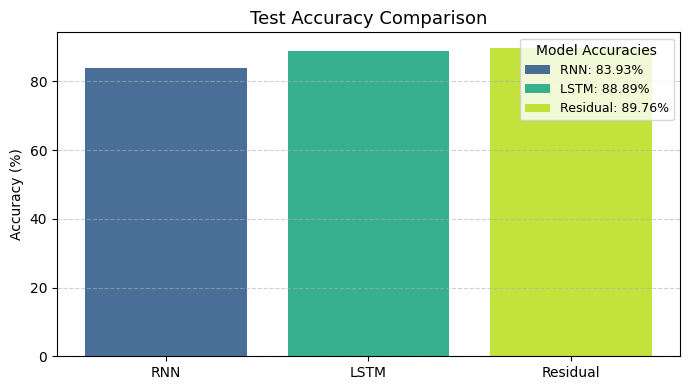

In [ ]:
models = ['RNN', 'LSTM', 'Residual']
acc_values = [rnn_test_acc, lstm_test_acc, residual_test_acc]
ppl_values = [rnn_test_ppl, lstm_test_ppl, residual_test_ppl]

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(models)))

plt.figure(figsize=(7, 4))
bars = plt.bar(models, acc_values, color=colors, alpha=0.9, label=[f"{m}: {v:.2f}%" for m, v in zip(models, acc_values)])

plt.title('Test Accuracy Comparison', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Model Accuracies", loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

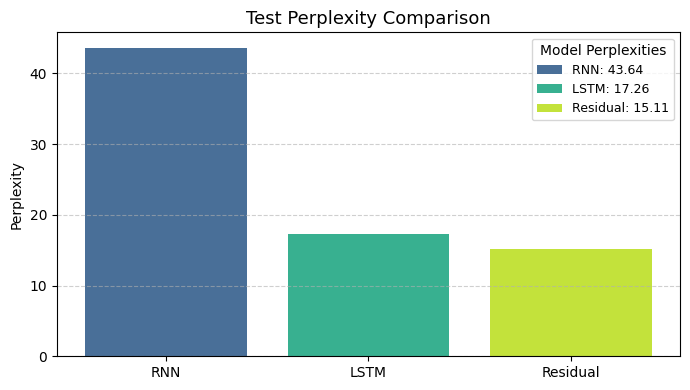

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(models, ppl_values, color=colors, alpha=0.9, label=[f"{m}: {v:.2f}" for m, v in zip(models, ppl_values)])

plt.title('Test Perplexity Comparison', fontsize=13)
plt.ylabel('Perplexity')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Model Perplexities", loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### **3.6) Saving the Best Model**

**`Checkpoint - 2 (final check)`**

In [ ]:
print("\nComparing model performance and saving the best model...")

rnn_final = torch.load("RNN_Baseline_22CS10087.pt", weights_only = False).to(device)
lstm_final = torch.load("LSTM_Baseline_22CS10087.pt", weights_only = False).to(device)
residual_final = torch.load("Residual_LSTM_22CS10087.pt", weights_only = False).to(device)

rnn_test_acc = eval['RNN']['Acc']
lstm_test_acc = eval['LSTM']['Acc']
residual_test_acc = eval['Residual']['Acc']

best_model = None
max_acc = 0.0
name = ""

if rnn_test_acc > max_acc:
    max_acc = rnn_test_acc
    best_model = rnn_final
    name = "RNN_Baseline_22CS10087"

if lstm_test_acc > max_acc:
    max_acc = lstm_test_acc
    best_model = lstm_final
    name = "LSTM_Baseline_22CS10087"

if residual_test_acc > max_acc:
    max_acc = residual_test_acc
    best_model = residual_final
    name = "Residual_LSTM_22CS10087"


torch.save(best_model, "best_model_22CS10087.pt")
print()
print(f"[+] Best Model: {name}.pt saved as best_model_22CS10087.pt")
print(f"[+] Best Model Accuracy: {max_acc:.2f}%")


Comparing model performance and saving the best model...

[+] Best Model: Residual_LSTM_22CS10087.pt saved as best_model_22CS10087.pt
[+] Best Model Accuracy: 89.76%
